In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head())
print(df.info)

  ticker  commodity       date       open       high        low      close  \
0   CL=F  Crude Oil  8/23/2000  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  8/24/2000  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  8/25/2000  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  8/28/2000  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  8/29/2000  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  
<bound method DataFrame.info of       ticker        commodity       date       open       high        low  \
0       CL=F        Crude Oil  8/23/2000  31.950001  32.799999  31.950001   
1       CL=F        Crude Oil  8/24/2000  31.900000  32.240002  31.400000   
2       CL=F        Crude Oil  8/25/2000  31.700001  32.099998  31.320000   
3       CL=F        Crude Oil  8/28/2000  32.040001  32.919998  31.860001   
4       CL=F        Crude Oil  8/29/2000  

In [3]:
print("\n=== Các loại hàng hóa có trong dữ liệu ===")
print(df['commodity'].unique())


=== Các loại hàng hóa có trong dữ liệu ===
['Crude Oil' 'Heating Oil' 'Natural Gas' 'RBOB Gasoline' 'Brent Crude Oil']


In [4]:
# 3. Xử lý cột ngày tháng
df['date'] = pd.to_datetime(df['date'])

# Set Date làm index
df.set_index('date', inplace=True)

In [5]:
# 5. Kiểm tra missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 ticker       0
commodity    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [6]:
print(df.columns)

Index(['ticker', 'commodity', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [7]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
if df.index.name == 'date':
    df.reset_index(inplace=True)

In [8]:
print(df.columns)

Index(['date', 'ticker', 'commodity', 'open', 'high', 'low', 'close',
       'volume'],
      dtype='object')


In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [10]:
# Kiểm tra missing
print("\nMissing date values:", df['date'].isnull().sum())


Missing date values: 0


In [11]:
df.describe()

,date,open,high,low,close,volume
count,28075,28075.000000,28075.000000,28075.000000,28075.000000,2.807500e+04
mean,2013-02-15 07:20:35.476402432,27.288994,27.680580,26.873389,27.287224,1.059926e+05
min,2000-08-23 00:00:00,-14.000000,0.507000,-40.320000,-37.630001,0.000000e+00
25%,2007-09-11 00:00:00,2.031000,2.060550,1.998200,2.031250,2.641100e+04
50%,2013-04-23 00:00:00,3.374000,3.450000,3.301000,3.375900,4.903300e+04
75%,2018-11-21 00:00:00,54.895000,55.745001,53.910000,54.900000,1.147245e+05
max,2024-06-24 00:00:00,146.080002,147.429993,144.270004,146.080002,2.288230e+06
std,NaN,36.085625,36.540236,35.599243,36.089001,1.484400e+05


In [12]:
# Kiểm tra xem dữ liệu có ngày bị thiếu không
# vì là tần suất ngày liên tục nên có thể bị thiếu mà các ngày đó
# có thể là ngày nghỉ, lễ, chủ nhật hay ngày gì đó nên ko cần điền giá trị vào
# nếu muốn xử lý thì có thể xử lý ở bước đánh index cho cột date bằng cách reindex
# reindex để bắt buộc thêm vào đầy đủ các ngày để đám bảo tính liên tục dù gây ra ở các cột khác ko có dữ liệu (áp dụng cho mô hình time series truyền thống
# sau khi reindex thì phải xử lý các giá trị NAN đó tùy thuộc vô mô hình, phương pháp dự báo cần làm

date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = date_range.difference(df['date'])

print("Các ngày thiếu trong dữ liệu:", missing_dates)

Các ngày thiếu trong dữ liệu: DatetimeIndex(['2000-08-26', '2000-08-27', '2000-09-02', '2000-09-03',
               '2000-09-04', '2000-09-09', '2000-09-10', '2000-09-16',
               '2000-09-17', '2000-09-23',
               ...
               '2024-05-27', '2024-06-01', '2024-06-02', '2024-06-08',
               '2024-06-09', '2024-06-15', '2024-06-16', '2024-06-19',
               '2024-06-22', '2024-06-23'],
              dtype='datetime64[ns]', length=2717, freq=None)


In [13]:
columns = ['date', 'ticker', 'commodity', 'open', 'high', 'low', 'close', 'volume']

for col in columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (df[col] <= 0).sum())
    else:
        print(f"Cột {col} không phải số, bỏ qua.")


Cột date không phải số, bỏ qua.
Cột ticker không phải số, bỏ qua.
Cột commodity không phải số, bỏ qua.
Giá trị open nhỏ hơn hoặc bằng 0: 1
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 2
Giá trị close nhỏ hơn hoặc bằng 0: 1
Giá trị volume nhỏ hơn hoặc bằng 0: 107


In [14]:
for col in ['open', 'high', 'low', 'close']:
    df[col] = df[col].apply(lambda x: x if x > 0 else df[col].mean())  # Thay bằng giá trị trung bình của cột


In [15]:
df['volume'] = df['volume'].apply(lambda x: x if x > 0 else df['volume'].mean())  # Thay bằng giá trị trung bình

In [16]:
columns = ['date', 'ticker', 'commodity', 'open', 'high', 'low', 'close', 'volume']

for col in columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (df[col] <= 0).sum())
    else:
        print(f"Cột {col} không phải số, bỏ qua.")


Cột date không phải số, bỏ qua.
Cột ticker không phải số, bỏ qua.
Cột commodity không phải số, bỏ qua.
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 0


In [17]:
df.describe()

,date,open,high,low,close,volume
count,28075,28075.000000,28075.000000,28075.000000,28075.000000,2.807500e+04
mean,2013-02-15 07:20:35.476402432,27.290465,27.680580,26.877336,27.289536,1.063965e+05
min,2000-08-23 00:00:00,0.427300,0.507000,0.376000,0.411800,1.000000e+00
25%,2007-09-11 00:00:00,2.031000,2.060550,1.998400,2.031550,2.665550e+04
50%,2013-04-23 00:00:00,3.374200,3.450000,3.303000,3.376000,4.955200e+04
75%,2018-11-21 00:00:00,54.895000,55.745001,53.910000,54.900000,1.147245e+05
max,2024-06-24 00:00:00,146.080002,147.429993,144.270004,146.080002,2.288230e+06
std,NaN,36.084783,36.540236,35.596032,36.086921,1.482952e+05


In [18]:
# Kiểm tra min, max date
print("Ngày đầu tiên:", df['date'].min())
print("Ngày cuối cùng:", df['date'].max())


Ngày đầu tiên: 2000-08-23 00:00:00
Ngày cuối cùng: 2024-06-24 00:00:00


In [19]:
# Thống kê trước khi điền dữ liệu
df_before_fill = df.copy()
print("Trước khi điền dữ liệu:")
print(df_before_fill.describe())

Trước khi điền dữ liệu:
                                date          open          high  \
count                          28075  28075.000000  28075.000000   
mean   2013-02-15 07:20:35.476402432     27.290465     27.680580   
min              2000-08-23 00:00:00      0.427300      0.507000   
25%              2007-09-11 00:00:00      2.031000      2.060550   
50%              2013-04-23 00:00:00      3.374200      3.450000   
75%              2018-11-21 00:00:00     54.895000     55.745001   
max              2024-06-24 00:00:00    146.080002    147.429993   
std                              NaN     36.084783     36.540236   

                low         close        volume  
count  28075.000000  28075.000000  2.807500e+04  
mean      26.877336     27.289536  1.063965e+05  
min        0.376000      0.411800  1.000000e+00  
25%        1.998400      2.031550  2.665550e+04  
50%        3.303000      3.376000  4.955200e+04  
75%       53.910000     54.900000  1.147245e+05  
max      144.

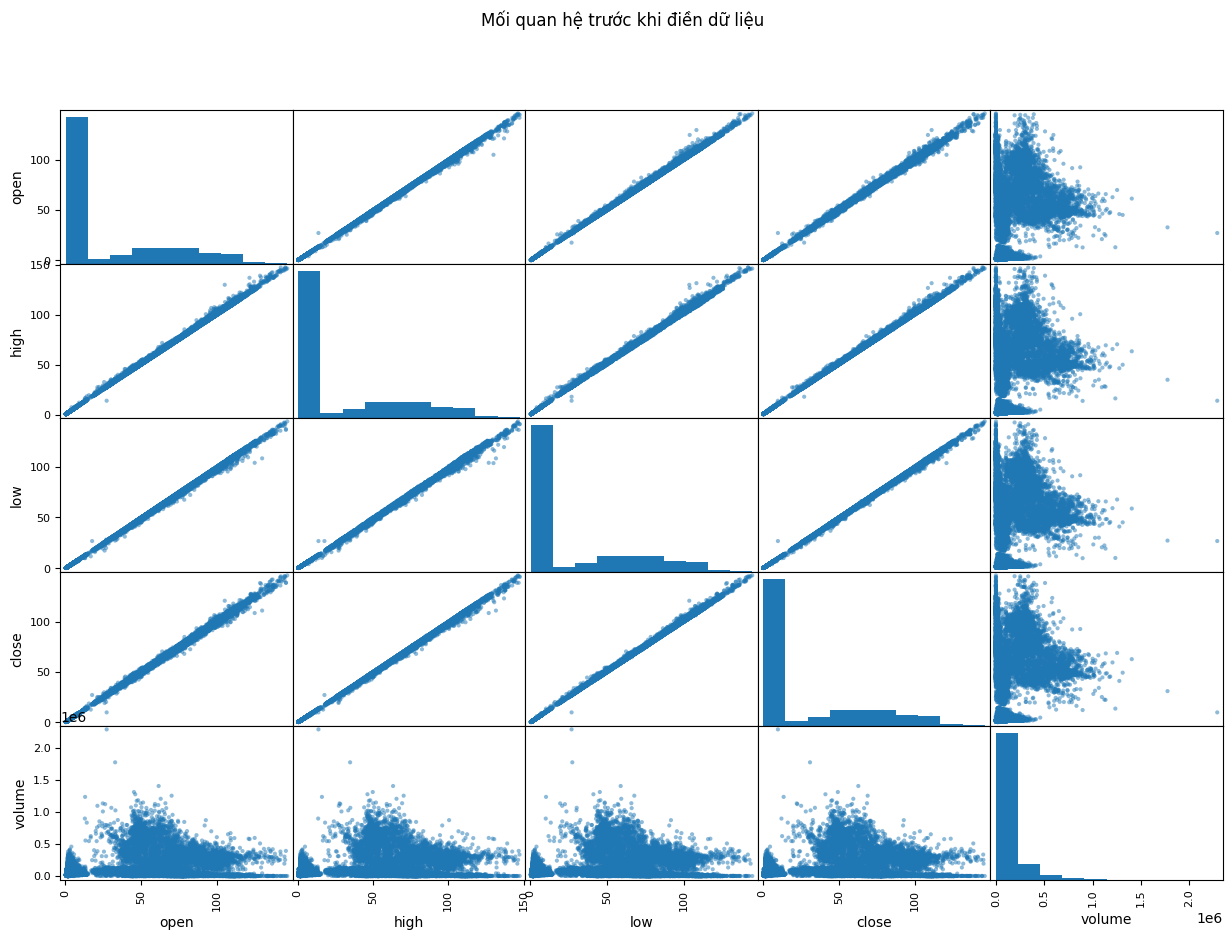

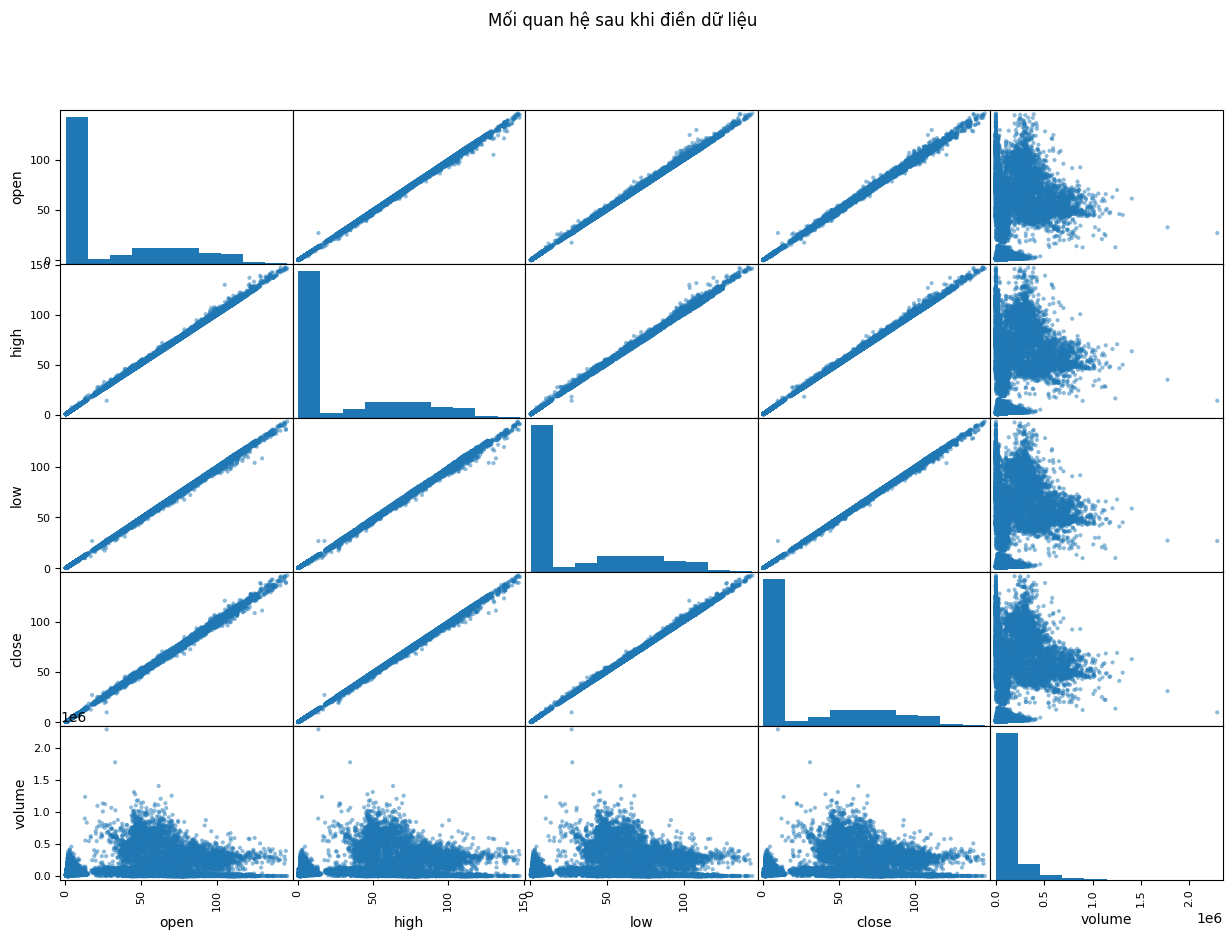

In [20]:
# Vẽ scatter plot giữa các cột trước khi điền dữ liệu
pd.plotting.scatter_matrix(df_before_fill[['open', 'high', 'low', 'close', 'volume']], figsize=(15, 10))
plt.suptitle('Mối quan hệ trước khi điền dữ liệu')
plt.show()

# Vẽ scatter plot giữa các cột sau khi điền dữ liệu
pd.plotting.scatter_matrix(df[['open', 'high', 'low', 'close', 'volume']], figsize=(15, 10))
plt.suptitle('Mối quan hệ sau khi điền dữ liệu')
plt.show()


In [37]:
df.head()

,date,ticker,commodity,open,high,low,close,volume
0,2000-08-23,CL=F,Crude Oil,31.950001,32.799999,31.950001,32.049999,79385.0
1,2000-08-24,CL=F,Crude Oil,31.900000,32.240002,31.400000,31.629999,72978.0
2,2000-08-25,CL=F,Crude Oil,31.700001,32.099998,31.320000,32.049999,44601.0
3,2000-08-28,CL=F,Crude Oil,32.040001,32.919998,31.860001,32.869999,46770.0
4,2000-08-29,CL=F,Crude Oil,32.820000,33.029999,32.560001,32.720001,49131.0


In [ ]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
if df.index.name == 'date':
    df.reset_index(inplace=True)

In [39]:
df.head()

,date,ticker,commodity,open,high,low,close,volume
0,2000-08-23,CL=F,Crude Oil,31.950001,32.799999,31.950001,32.049999,79385.0
1,2000-08-24,CL=F,Crude Oil,31.900000,32.240002,31.400000,31.629999,72978.0
2,2000-08-25,CL=F,Crude Oil,31.700001,32.099998,31.320000,32.049999,44601.0
3,2000-08-28,CL=F,Crude Oil,32.040001,32.919998,31.860001,32.869999,46770.0
4,2000-08-29,CL=F,Crude Oil,32.820000,33.029999,32.560001,32.720001,49131.0


In [ ]:
# 2. Khởi tạo dict để chứa 5 DataFrame
series_dict = {}

# 3. Group và xử lý riêng cho từng commodity
for comm, grp in df.groupby('commodity'):
    # a) Chuyển đảm bảo 'date' là datetime (parse_dates đã làm, nhưng thêm cho chắc)
    grp['date'] = pd.to_datetime(grp['date'])
    
    # b) Sort theo ngày rồi đặt làm index
    grp = grp.sort_values('date').set_index('date')
    
    # c) (Tuỳ chọn) Reindex để có đủ khung ngày (chỉ dùng cho holt-winters, ARMIA, SARIMA,... )
    #Nếu bạn xác định dùng Holt-Winters và forecast đều mỗi ngày, thì nên reindex.
    #Nếu bạn chỉ muốn phân tích theo ngày giao dịch thật (ví dụ xem xu hướng mà không dự đoán theo ngày) thì không cần reindex.
    
    # full_idx = pd.date_range(start=grp.index.min(), end=grp.index.max(), freq='D')
    # grp = grp.reindex(full_idx)
    
    # d) Lưu lại DataFrame đã set_index
    series_dict[comm] = grp

# 4. Truy cập:
#   - Crude Oil:   series_dict['Crude Oil']
#   - Brent:       series_dict['Brent Crude Oil']
#   - Natural Gas: series_dict['Natural Gas']
#   - … v.v.



In [41]:
# Ví dụ in ra thông tin từng DataFrame
for comm, df_comm in series_dict.items():
    print(f"{comm}: {len(df_comm)} rows, index từ {df_comm.index.min()} đến {df_comm.index.max()}")

Brent Crude Oil: 4196 rows, index từ 2007-07-30 00:00:00 đến 2024-06-24 00:00:00
Crude Oil: 5984 rows, index từ 2000-08-23 00:00:00 đến 2024-06-24 00:00:00
Heating Oil: 5977 rows, index từ 2000-09-01 00:00:00 đến 2024-06-24 00:00:00
Natural Gas: 5980 rows, index từ 2000-08-30 00:00:00 đến 2024-06-24 00:00:00
RBOB Gasoline: 5938 rows, index từ 2000-11-01 00:00:00 đến 2024-06-24 00:00:00


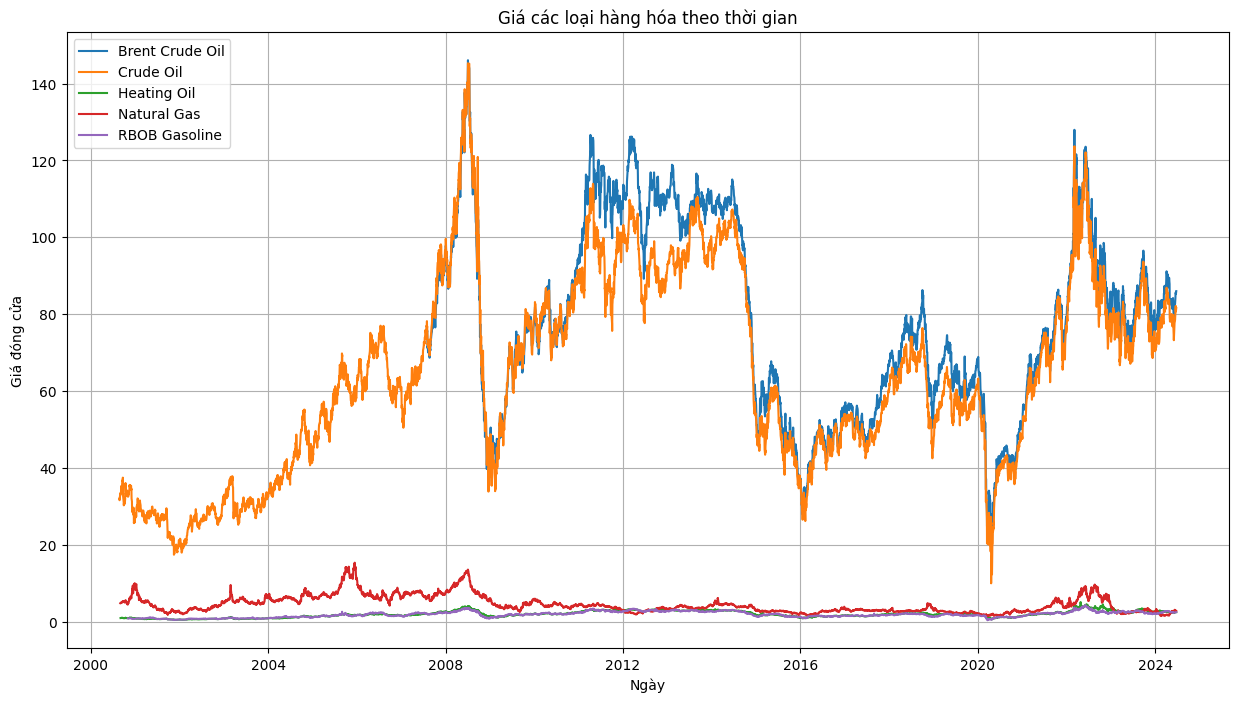

In [43]:
import matplotlib.pyplot as plt

# Vẽ tất cả các commodity trên cùng một biểu đồ
plt.figure(figsize=(15, 8))

for comm, df_comm in series_dict.items():
    plt.plot(df_comm.index, df_comm['close'], label=comm)  # giả sử cột giá cần vẽ là 'Close'

plt.title('Giá các loại hàng hóa theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True)
plt.show()


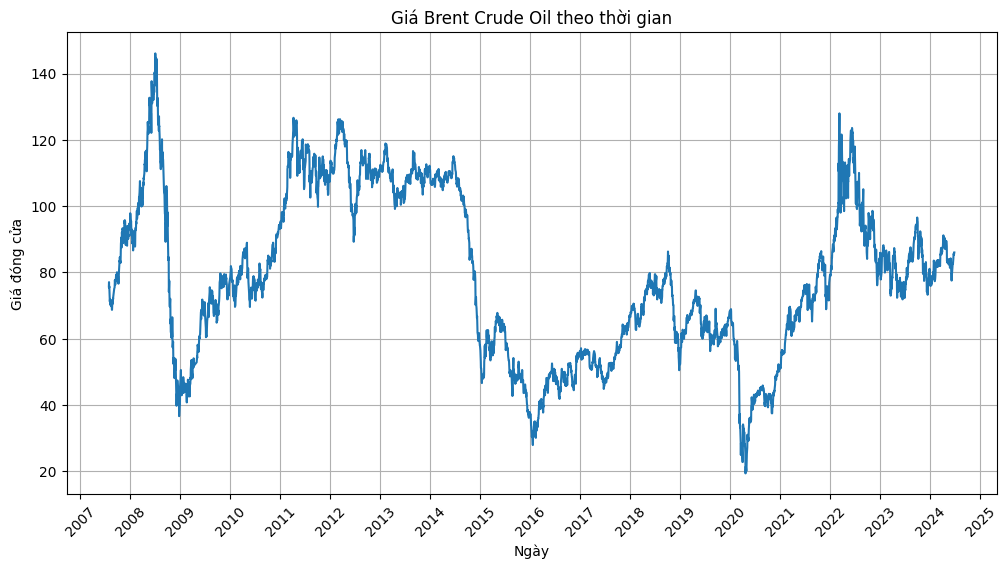

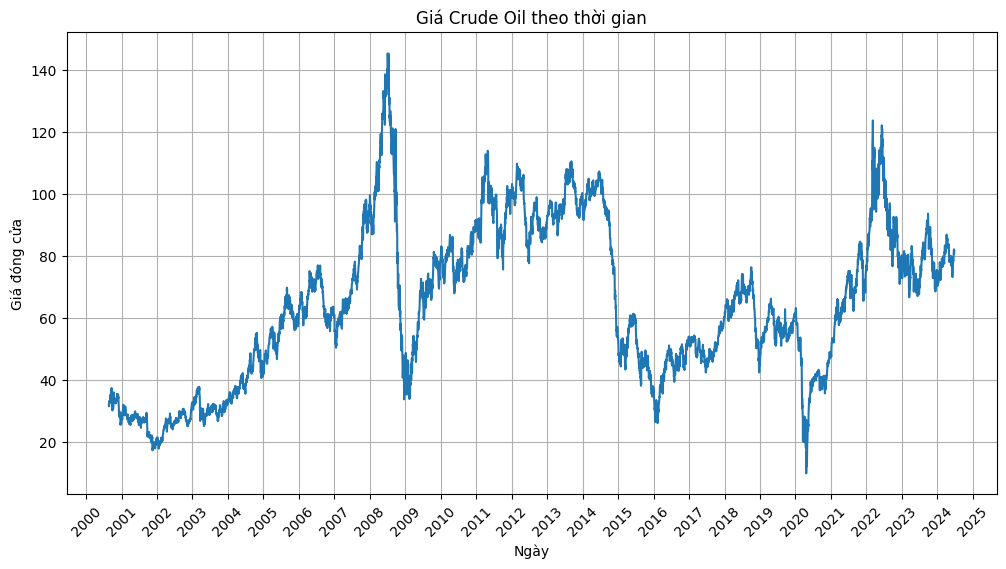

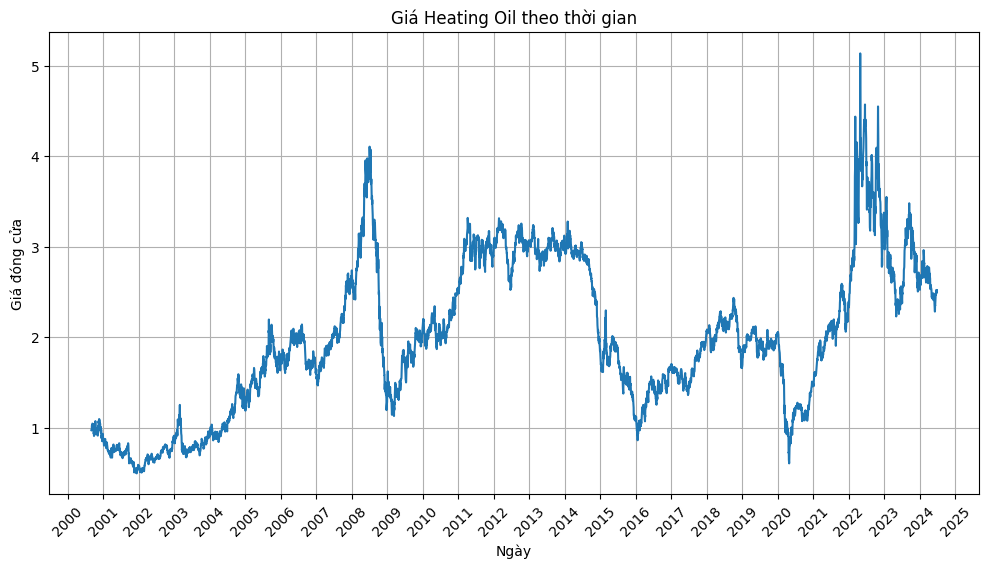

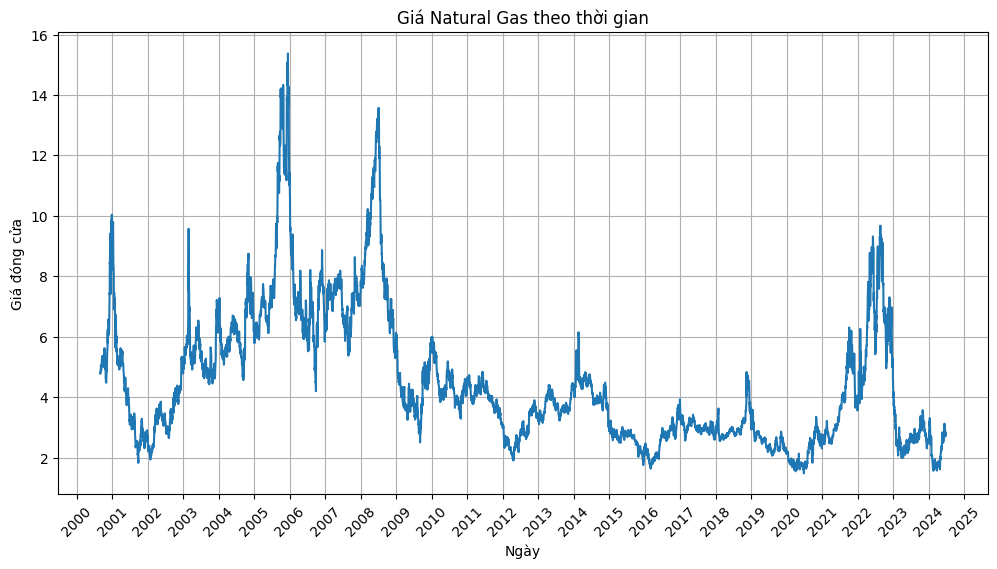

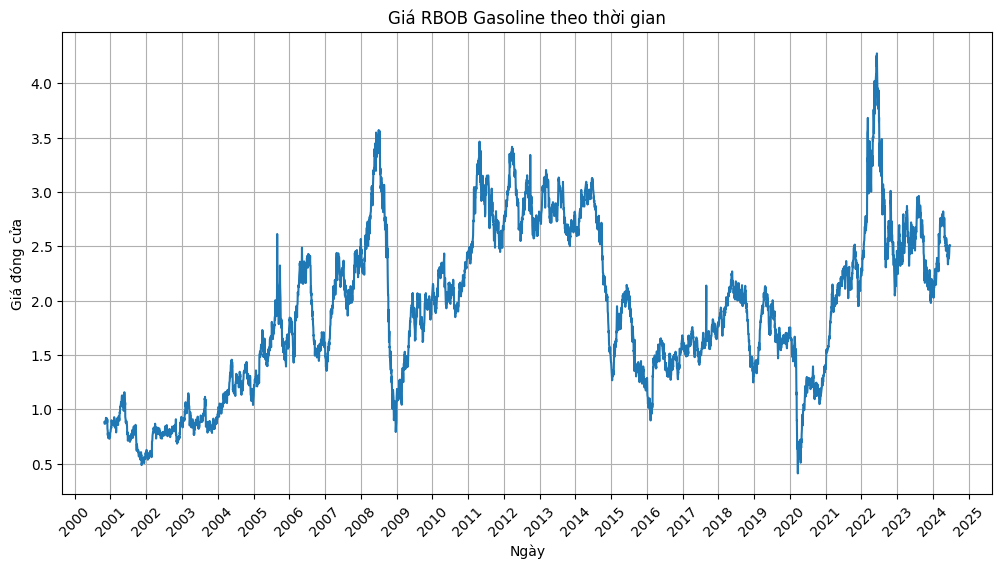

In [45]:
import matplotlib.dates as mdates

for comm, df_comm in series_dict.items():
    plt.figure(figsize=(12, 6))
    plt.plot(df_comm.index, df_comm['close'])
    plt.title(f'Giá {comm} theo thời gian')
    plt.xlabel('Ngày')
    plt.ylabel('Giá đóng cửa')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# tiếp tục làm các bước xử lý cần thiết cho mô hình - phương pháp dự báo cần sử dụng